In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer, SimpleImputer
from spicy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
data={
    'CustomerID': range(1,301),
    'Age': np.random.randint(18, 70, size=300),
    'Gender': np.random.choice(['Male', 'Female'], size = 300),
    'Country': np.random.choice(['USA','CANADA','Tunisia', 'France', 'Germany', 'UK'], size = 300),
    'ProductCategory': np.random.choice(['Electronics','Clothings','Home','Beauty','Books'],size=300),
    'PurchaseAmmount': np.round(np.random.uniform(5,500, size=300),2),
    'Rating': np.random.choice([1,2,3,4,5,np.nan],size=300),
    'Review': np.random.choice(["Poor","Bad","Average","Good","Excellent"],size=300),
    'PurshaseDate': pd.Series(pd.date_range(start="2022-01-01", periods=300, freq = 'D').append(pd.date_range(start="2010-01-01", periods=10, freq = 'D'))).sample(300).reset_index(drop=True),
    'LoyaltyMembers': np.random.choice(['Yes','No'], size=300),
    'Returned': np.random.choice(['Yes','No'], size=300),
    'Churned':np.random.choice(['Yes','No'],size=300)
}

In [ ]:
df=pd.DataFrame(data)

In [ ]:
#adding some misssing values
for col in ['Age', 'Rating']:
  df.loc[df.sample(frac=0.1).index,col] =np.nan

In [ ]:
#adding some outliers in PurchaseAmmount
df.loc[df.sample(frac=0.05).index, 'PurchaseAmmount'] = df['PurchaseAmmount']*10

In [ ]:
df.head(20)

,CustomerID,Age,Gender,Country,ProductCategory,PurchaseAmmount,Rating,Review,PurshaseDate,LoyaltyMembers,Returned,Churned
0,1,28.0,Male,USA,Electronics,157.38,2.0,Bad,2022-01-19,No,No,No
1,2,63.0,Male,USA,Electronics,466.00,4.0,Average,2022-04-10,No,Yes,Yes
2,3,56.0,Male,USA,Electronics,480.38,NaN,Good,2022-02-26,No,No,Yes
3,4,42.0,Female,CANADA,Clothings,424.41,3.0,Average,2022-10-20,No,No,No
4,5,32.0,Male,Tunisia,Electronics,154.20,1.0,Bad,2022-07-05,Yes,Yes,No
5,6,61.0,Male,UK,Books,34.31,3.0,Excellent,2022-07-27,No,Yes,Yes
6,7,32.0,Female,USA,Home,420.91,NaN,Bad,2022-05-25,No,No,Yes
7,8,36.0,Male,UK,Books,426.77,1.0,Average,2022-10-01,No,Yes,No
8,9,68.0,Male,Tunisia,Home,346.92,2.0,Bad,2022-04-06,No,No,No
9,10,38.0,Female,Germany,Books,230.04,1.0,Bad,2022-08-06,Yes,Yes,Yes


In [ ]:
#Impute Age using K nearest neighbor
Knn_imputer=KNNImputer(n_neighbors=5)
df['Age']=Knn_imputer.fit_transform(df[['Age']])


In [ ]:
mode_imputer=SimpleImputer(strategy='most_frequent')
df['Rating']=mode_imputer.fit_transform(df[['Rating']])

In [ ]:
pip install spicy

In [ ]:
#Handling outliers using standard deviation
Z_scores=np.abs(stats.zscore(df['PurchaseAmmount']))
df['PurchaseAmmount']=np.where(Z_scores>3, df['PurchaseAmmount'].median(),df['PurchaseAmmount'])

In [ ]:
df.describe()

,CustomerID,Age,PurchaseAmmount,Rating,PurshaseDate
count,300.000000,300.000000,300.000000,300.000000,300
mean,150.500000,42.281481,265.955667,3.286667,2021-12-31 18:19:12
min,1.000000,18.000000,10.320000,1.000000,2010-01-01 00:00:00
25%,75.750000,32.000000,129.130000,2.000000,2022-03-12 12:00:00
50%,150.500000,42.281481,246.705000,4.000000,2022-05-27 12:00:00
75%,225.250000,51.000000,393.750000,4.000000,2022-08-11 06:00:00
max,300.000000,69.000000,1623.900000,5.000000,2022-10-27 00:00:00
std,86.746758,13.916931,191.390053,1.287120,NaN


In [ ]:
Q1 = df['PurchaseAmmount'].quantile(0.25)
Q3 = df['PurchaseAmmount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1-1.5* IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
df["PurchaseAmmount"] = np.where(df["PurchaseAmmount"] > upper_bound,upper_bound, df["PurchaseAmmount"])

In [ ]:
start_date = pd.Timestamp('2022-01-01')
end_date = pd.Timestamp('2024-01-01')

df['PurshaseDate'] = df['PurshaseDate'].apply(lambda x: x if start_date<= x <= end_date else np.nan)

In [ ]:
median_date = df['PurshaseDate'].median()

In [ ]:
df['PurshaseDate'].fillna(median_date, inplace=True)

In [ ]:
review_map={'Poor':1,
            'Bad':2,
            'Average':3,
            'Good':4,
            'Excellent':5


}

In [ ]:
df['Review']=df['Review'].map(review_map)

In [ ]:
label_en=LabelEncoder()

In [ ]:
df['Gender']=label_en.fit_transform(df['Gender'])
df['Returned']=label_en.fit_transform(df['Returned'])
df['LoyaltyMembers']=label_en.fit_transform(df['LoyaltyMembers'])
df['Churned']=label_en.fit_transform(df['Churned'])

In [ ]:
df=pd.get_dummies(df,columns=['Country','ProductCategory'])

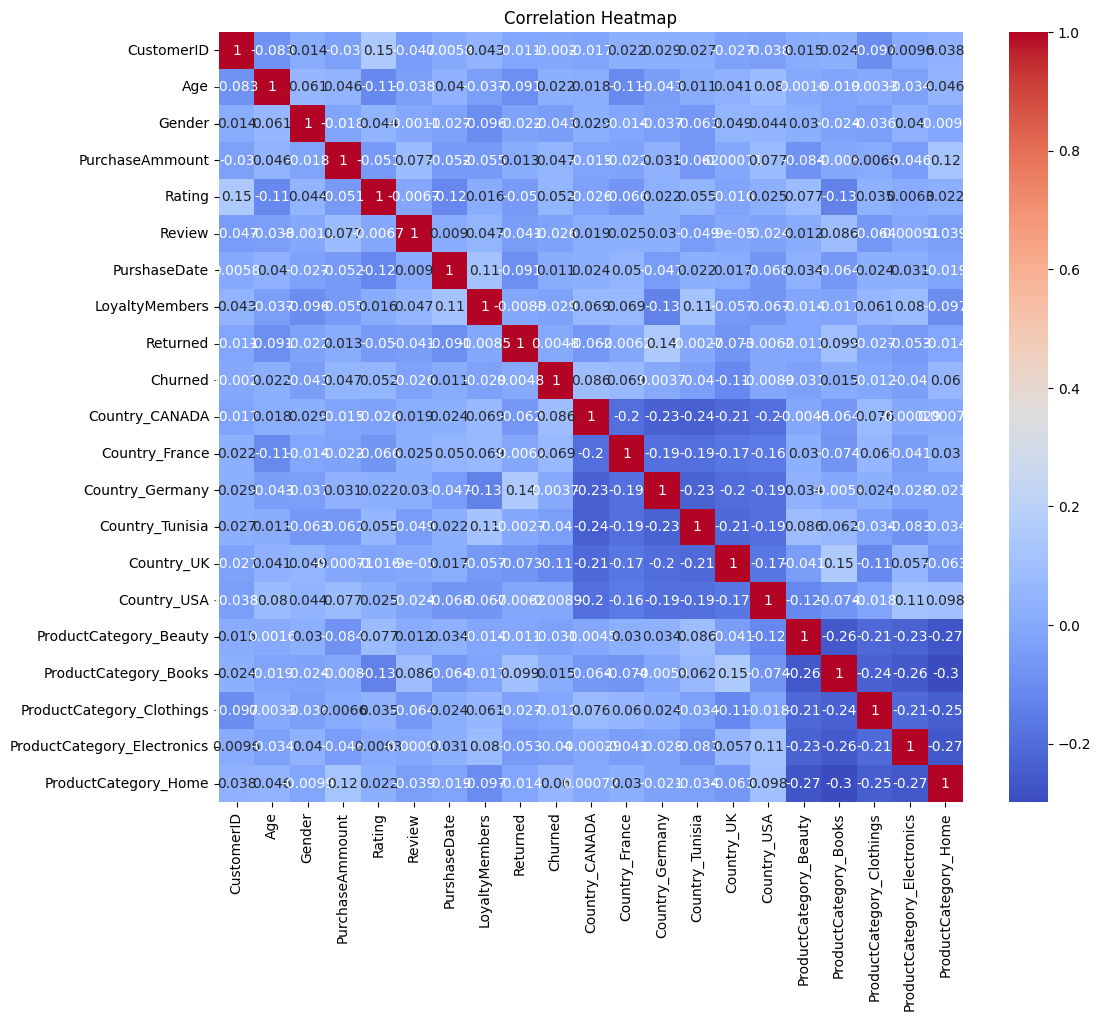

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

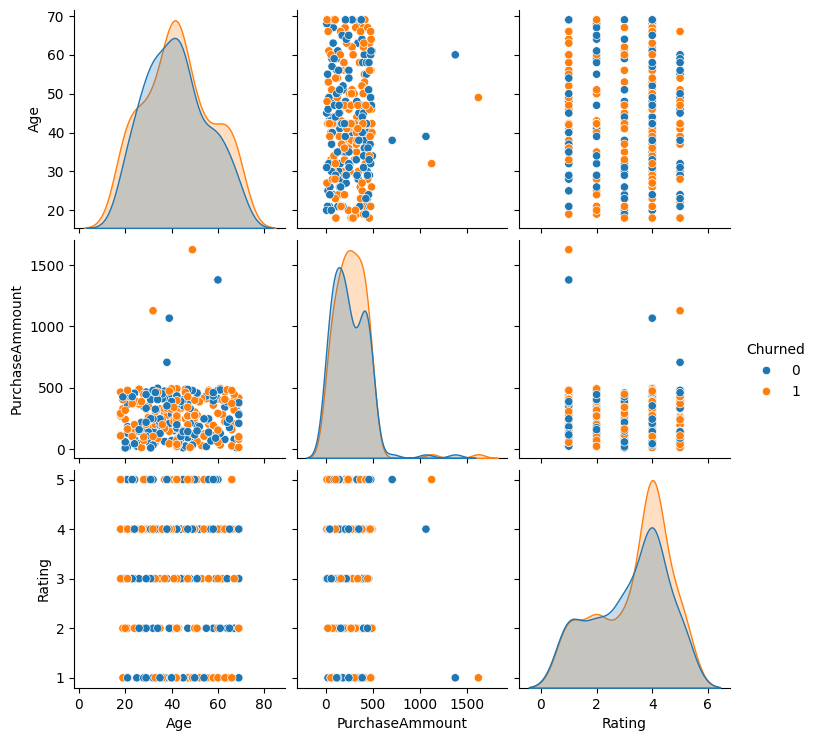

In [ ]:
sns.pairplot(df, hue='Churned', vars=['Age', 'PurchaseAmmount', 'Rating'])
plt.show()

In [ ]:
X=df.drop(columns=['CustomerID','Churned','PurshaseDate'])
y=df['Churned']

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2)
log_reg=LogisticRegression()
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
rf=RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
gbc=GradientBoostingClassifier(random_state=42)
gbc.fit(X_train,y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
models={'LR':log_reg,
        'rf':rf,
        'gbc':gbc
        }

In [ ]:
for name, model in models.items():
  y_pred=model.predict(X_test)
  print(f'{name} model accuracy: {accuracy_score(y_test,y_pred)}')

LR model accuracy: 0.43333333333333335
rf model accuracy: 0.4666666666666667
gbc model accuracy: 0.5333333333333333


In [ ]:
model_accuracies = {
    'log_reg': accuracy_score(y_test, log_reg.predict(X_test)),
    'Random Forest': accuracy_score(y_test, rf.predict(X_test)),
    'Gradient Boosting': accuracy_score(y_test, gbc.predict(X_test))
}

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(model_accuracies.keys(), model_accuracies.values(), color=['blue', 'green', 'red'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.show()